# **Prediction on what crop to grow**


## **Importing the libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

## **Reading the data and getting info of it**

In [ ]:
data=pd.read_csv('Crop_recommendation.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


## **Viewing the first 5 rows of data**

In [ ]:
data.head(5)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## **Counting the unique targeted values**

In [ ]:
data.reset_index(inplace=True, drop=True)
data['label'].value_counts()

rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: label, dtype: int64

## **Describing the data**

In [ ]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


#**Distribution plot for all the features**

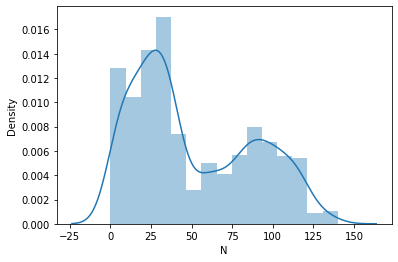

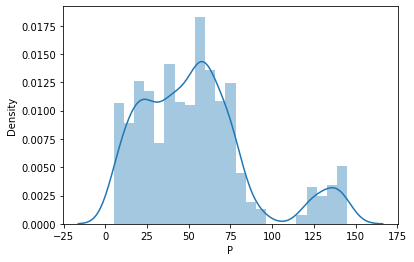

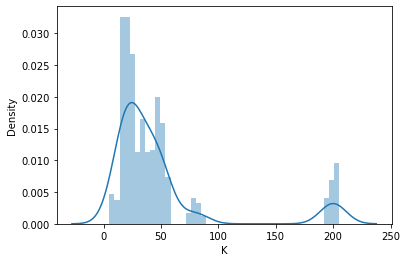

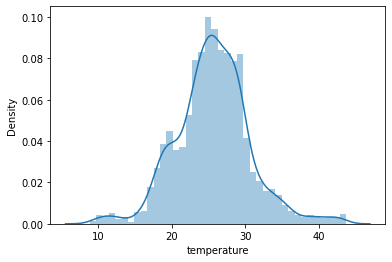

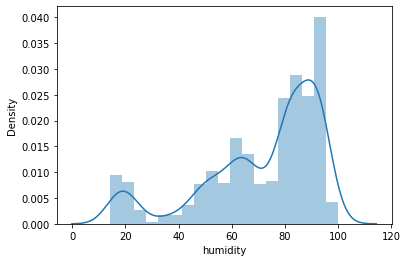

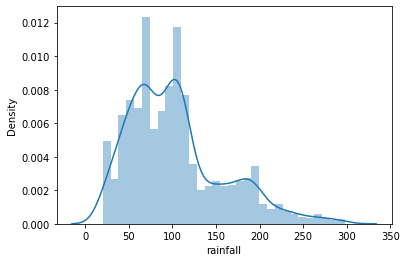

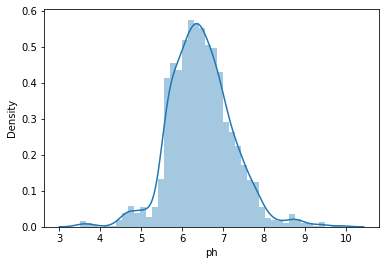

In [ ]:
sns.distplot(data.N)
plt.show()
sns.distplot(data.P)
plt.show()
sns.distplot(data.K)
plt.show()
sns.distplot(data.temperature)
plt.show()
sns.distplot(data.humidity)
plt.show()
sns.distplot(data.rainfall)
plt.show()
sns.distplot(data.ph)
plt.show()

# **Joint plot**

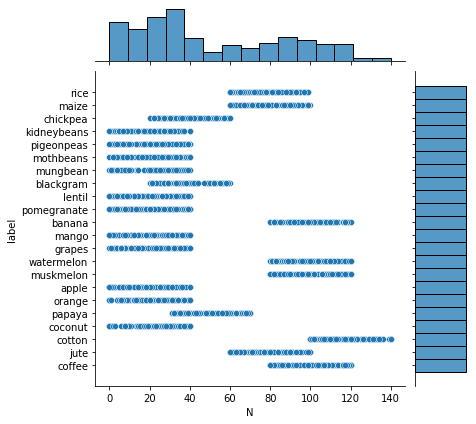

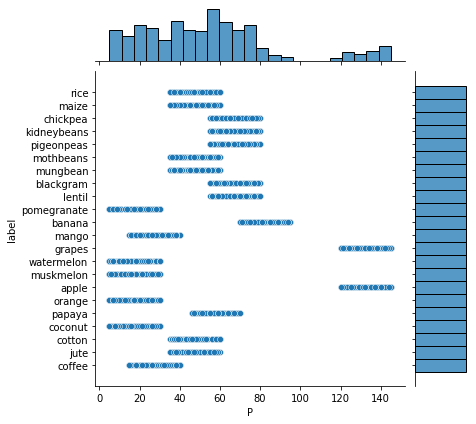

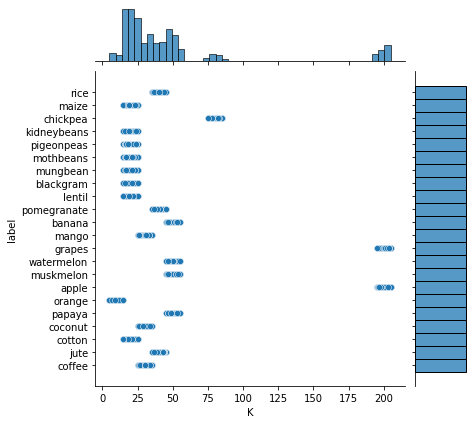

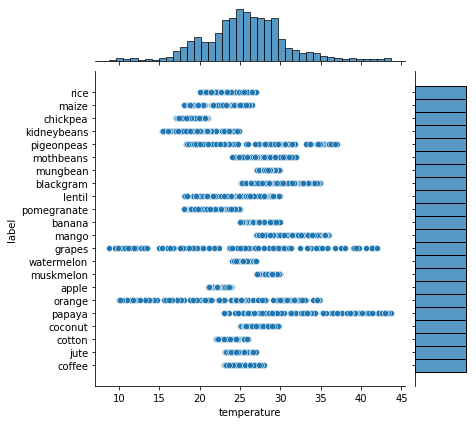

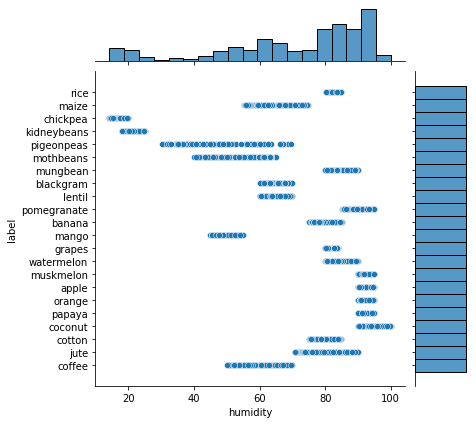

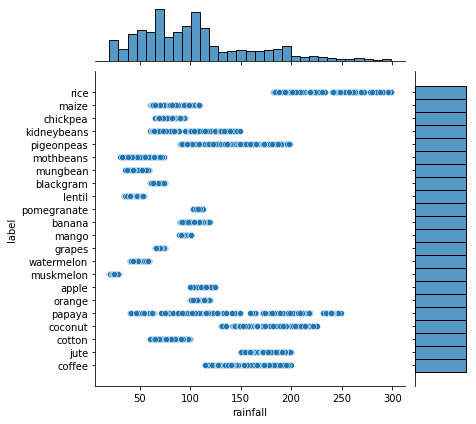

In [ ]:
sns.jointplot(data.N, data.label)
plt.show()
sns.jointplot(data.P, data.label)
plt.show()
sns.jointplot(data.K, data.label)
plt.show()
sns.jointplot(data.temperature, data.label)
plt.show()
sns.jointplot(data.humidity, data.label)
plt.show()
sns.jointplot(data.rainfall, data.label)
plt.show()

# **Pair plot for all features**

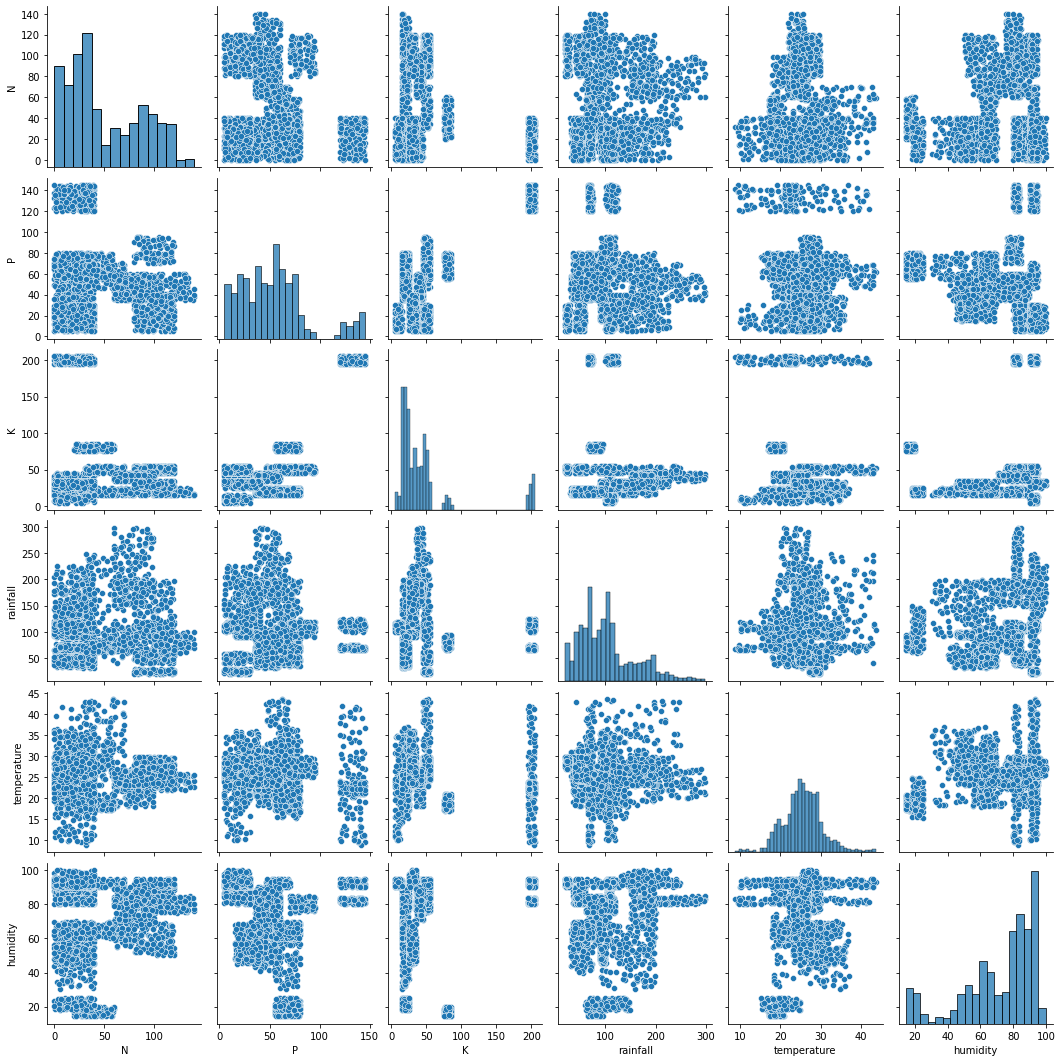

In [ ]:
sns.pairplot(data[[ 'N','P','K','rainfall','temperature','humidity', 'label']])
plt.show()

# **Generating heat map to know the corelation between features**

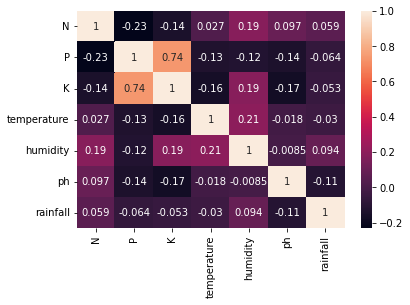

In [ ]:
sns.heatmap(data.corr(),annot=True)

# **Assigning the data**

In [ ]:
X = data.drop("label", axis=1)
Y = data["label"]

## **Splitting the data for training and testing**

In [ ]:
X_train, X_test, Y_train, Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y)

## **KNN Algorithm**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train,Y_train)
A=knn.predict(X_test)
knn_accuracy=accuracy_score(Y_test,A)*100
Names=['knn_algorithm']
Accuracy=[knn_accuracy]
print('Classification Report')
print(classification_report(Y_test, A))
print('KNN algorithm accuracy is ', knn_accuracy)

Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        25
    chickpea       1.00      1.00      1.00        14
     coconut       1.00      1.00      1.00        16
      coffee       1.00      1.00      1.00        22
      cotton       0.91      1.00      0.95        10
      grapes       1.00      1.00      1.00        23
        jute       0.91      0.95      0.93        22
 kidneybeans       1.00      1.00      1.00        18
      lentil       1.00      0.96      0.98        28
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        21
   mothbeans       0.95      1.00      0.98        21
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        21
      orange       1.00      1.00      1.00        18
     

## **Confusion Matrix for knn**

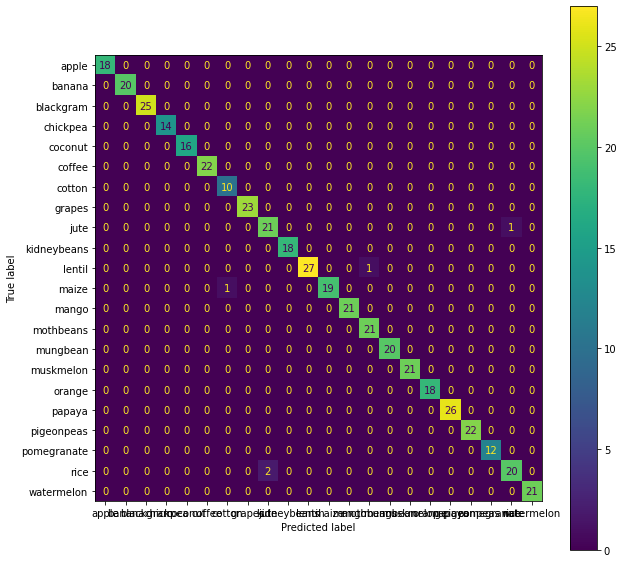

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(Y_test, A,ax=ax)

## **SVM algorithm**

In [ ]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(X_train,Y_train)
s=svm.predict(X_test)
svm_accuracy=accuracy_score(Y_test,s)*100
Names.append('SVM_algorithm')
Accuracy.append(svm_accuracy)
print('Classification Report')
print(classification_report(Y_test,s))
print("SVM algorithm Accuracy is: ",svm_accuracy)

Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.96      0.98        25
    chickpea       1.00      1.00      1.00        14
     coconut       1.00      1.00      1.00        16
      coffee       1.00      1.00      1.00        22
      cotton       0.83      1.00      0.91        10
      grapes       1.00      1.00      1.00        23
        jute       0.88      1.00      0.94        22
 kidneybeans       0.90      1.00      0.95        18
      lentil       0.97      1.00      0.98        28
       maize       1.00      0.90      0.95        20
       mango       1.00      1.00      1.00        21
   mothbeans       1.00      1.00      1.00        21
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        21
      orange       1.00      1.00      1.00        18
     

## **Confusion Matrix for SVM**

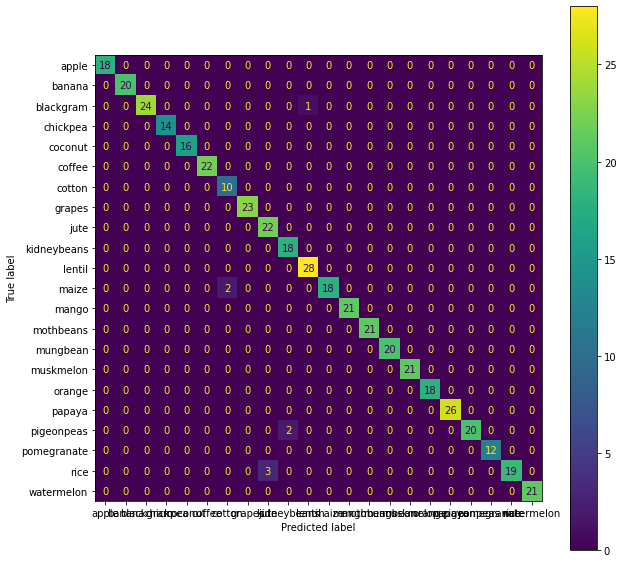

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(Y_test, s,ax=ax)

## **NaiveBayes Algorithm**

In [ ]:
from sklearn.naive_bayes import GaussianNB
naive = GaussianNB()
naive.fit(X_train,Y_train)
n=naive.predict(X_test)
naivebayes_accuracy=accuracy_score(Y_test,n)*100
Names.append('Naviebayes_algorithm')
Accuracy.append(naivebayes_accuracy)
naivebayes_accuracy
print('Classification Report')
print(classification_report(Y_test,n))
print("NavieBayes Algorithm Accuracy is: ",naivebayes_accuracy)

Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        25
    chickpea       1.00      1.00      1.00        14
     coconut       1.00      1.00      1.00        16
      coffee       1.00      1.00      1.00        22
      cotton       0.91      1.00      0.95        10
      grapes       1.00      1.00      1.00        23
        jute       1.00      1.00      1.00        22
 kidneybeans       1.00      1.00      1.00        18
      lentil       1.00      1.00      1.00        28
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        21
   mothbeans       1.00      1.00      1.00        21
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        21
      orange       1.00      1.00      1.00        18
     

## **Confusion Matrix for NaiveBayes**

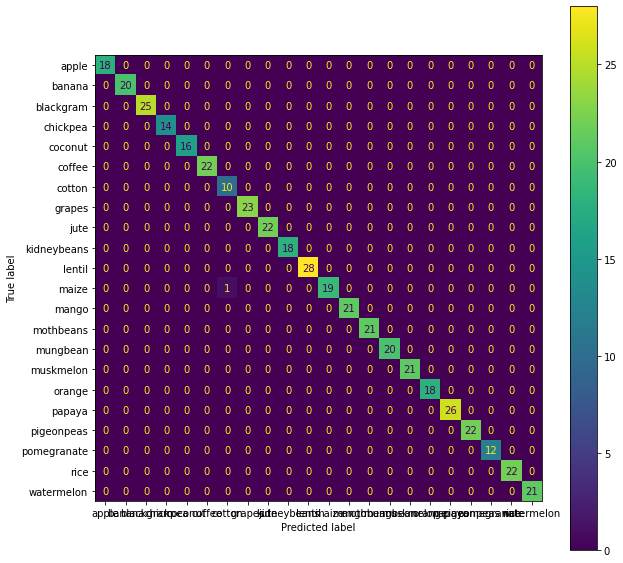

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(Y_test, n,ax=ax)

## **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier()
tree.fit(X_train,Y_train)
c=tree.predict(X_test)
DecisionTree_accuracy=accuracy_score(Y_test,c)*100
Names.append('DecisionTree_algorithm')
Accuracy.append(DecisionTree_accuracy)
print('Classification Report')
print(classification_report(Y_test, c))
print("DecisionTress Acuracy is ",DecisionTree_accuracy)

Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        20
   blackgram       0.88      0.92      0.90        25
    chickpea       1.00      1.00      1.00        14
     coconut       1.00      0.94      0.97        16
      coffee       0.96      1.00      0.98        22
      cotton       1.00      1.00      1.00        10
      grapes       1.00      1.00      1.00        23
        jute       1.00      0.91      0.95        22
 kidneybeans       1.00      1.00      1.00        18
      lentil       0.93      1.00      0.97        28
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        21
   mothbeans       1.00      0.86      0.92        21
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        21
      orange       0.95      1.00      0.97        18
     

## **Confusion Matrix for Decision Tree**

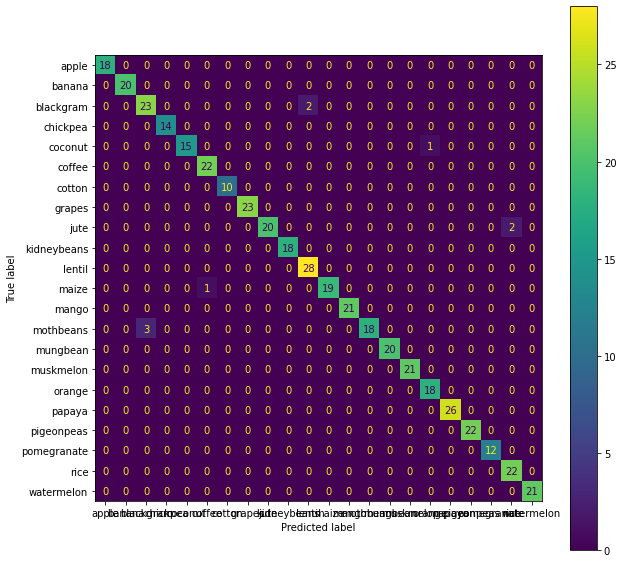

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(Y_test, c,ax=ax)

<BarContainer object of 7 artists>

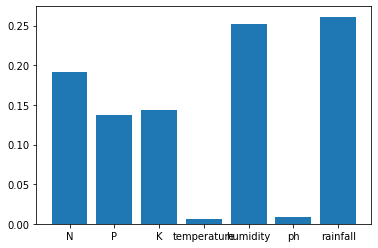

In [ ]:
import matplotlib.pyplot as plt
plt.bar(X.columns, tree.feature_importances_)

## **Random Forest Algorithm**

In [ ]:
#Random forest classification
from sklearn.ensemble import RandomForestClassifier
random=RandomForestClassifier()
random.fit(X_train,Y_train)
r=random.predict(X_test)
RandomForest_accuracy=accuracy_score(Y_test,r)*100
Names.append('RandomForest_algorithm')
Accuracy.append(RandomForest_accuracy)
RandomForest_accuracy
print('Classification Report')
print(classification_report(Y_test,r))
print("Random Forest Accuracy is: ",RandomForest_accuracy)

Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        25
    chickpea       1.00      1.00      1.00        14
     coconut       1.00      1.00      1.00        16
      coffee       1.00      1.00      1.00        22
      cotton       1.00      1.00      1.00        10
      grapes       1.00      1.00      1.00        23
        jute       1.00      1.00      1.00        22
 kidneybeans       1.00      1.00      1.00        18
      lentil       1.00      1.00      1.00        28
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        21
   mothbeans       1.00      1.00      1.00        21
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        21
      orange       1.00      1.00      1.00        18
     

## **Confusion Matrix for RandomForest**

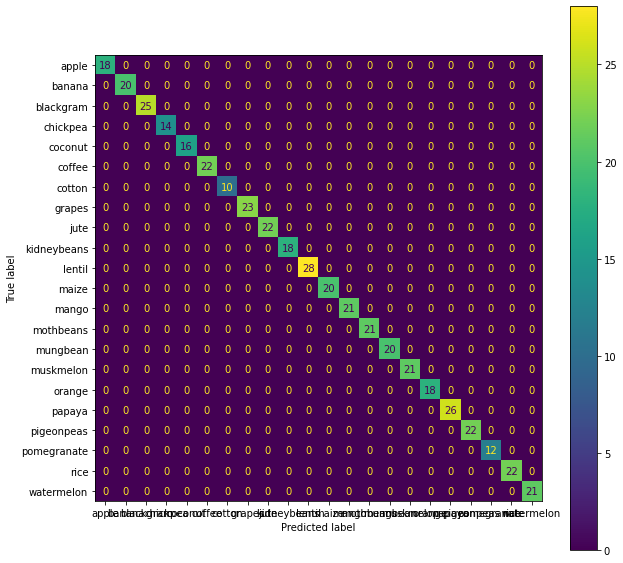

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(Y_test, r,ax=ax)

<BarContainer object of 7 artists>

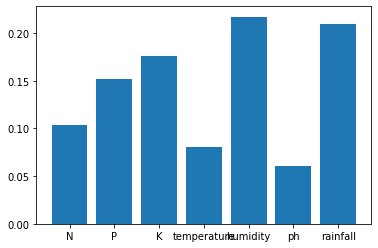

In [ ]:
import matplotlib.pyplot as plt
plt.bar(X.columns, random.feature_importances_)

## **Arranging the accuracies**

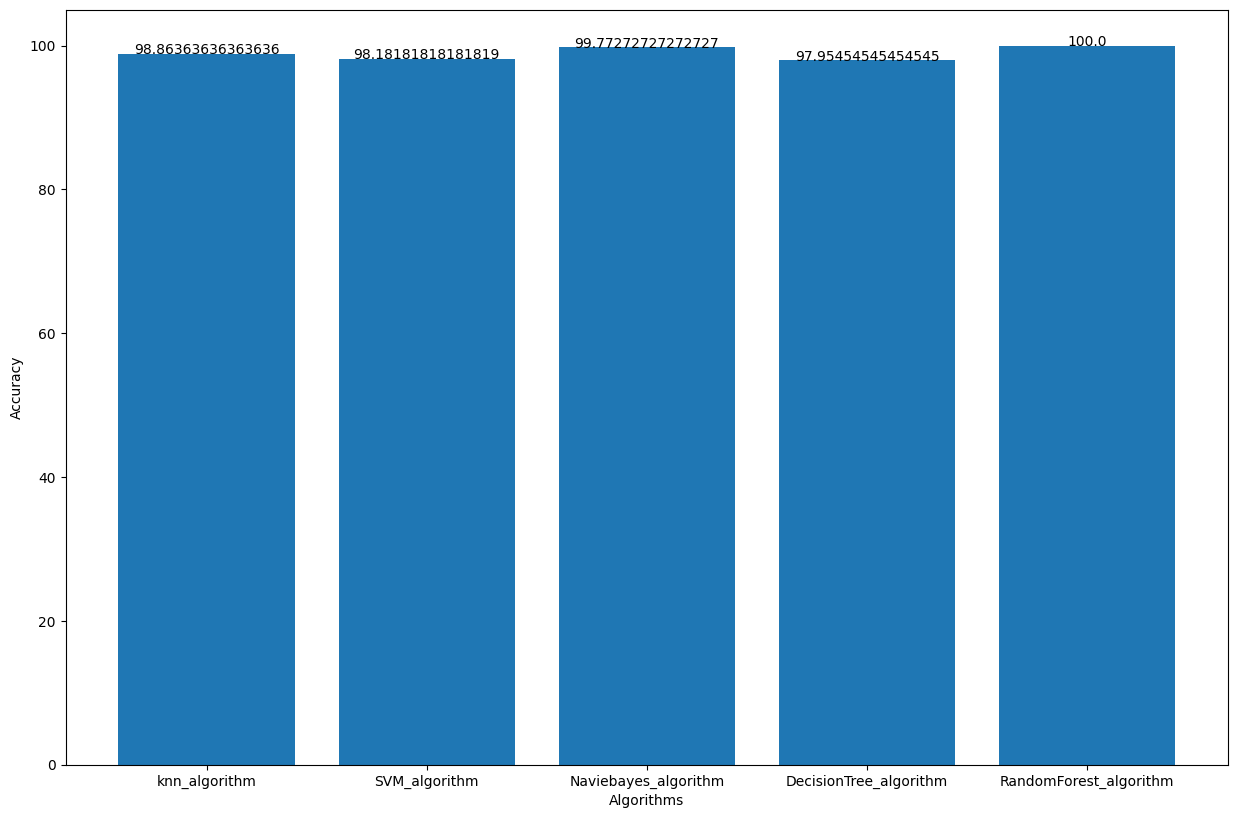

In [ ]:
plt.figure(figsize=[15,10],dpi=100)

plt.bar(Names,Accuracy)
for i in range(len(Names)):
  plt.text(i,Accuracy[i],Accuracy[i],ha = 'center')
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
#!pip install flaml

## **Automation using Microsoft's flaml**

In [ ]:
from flaml import AutoML
automl=AutoML()
settings = {
    "time_budget": 60*60,
    "estimator_list": ['lgbm', 'extra_tree', 'xgb_limitdepth', 'lrl1','xgboost','lrl2'],
    "metric": 'accuracy',
    "task": 'classification',
    "log_file_name": 'crop_recommend.log',
}
automl.fit(X_train,Y_train,**settings)

Streaming output truncated to the last 5000 lines.
[flaml.automl: 12-14 05:08:49] {3166} INFO - iteration 1723, current learner lgbm
INFO:flaml.automl:iteration 1723, current learner lgbm
[flaml.automl: 12-14 05:08:49] {3343} INFO -  at 2346.8s,	estimator lgbm's best error=0.0034,	best estimator lgbm's best error=0.0034
INFO:flaml.automl: at 2346.8s,	estimator lgbm's best error=0.0034,	best estimator lgbm's best error=0.0034
[flaml.automl: 12-14 05:08:49] {3166} INFO - iteration 1724, current learner lgbm
INFO:flaml.automl:iteration 1724, current learner lgbm
[flaml.automl: 12-14 05:08:50] {3343} INFO -  at 2347.4s,	estimator lgbm's best error=0.0034,	best estimator lgbm's best error=0.0034
INFO:flaml.automl: at 2347.4s,	estimator lgbm's best error=0.0034,	best estimator lgbm's best error=0.0034
[flaml.automl: 12-14 05:08:50] {3166} INFO - iteration 1725, current learner lgbm
INFO:flaml.automl:iteration 1725, current learner lgbm
[flaml.automl: 12-14 05:08:51] {3343} INFO -  at 2348.1s

## **Best algorithm in AutoMl**

In [ ]:
print(automl.model.estimator)

LGBMClassifier(colsample_bytree=0.6753922366943279,
               learning_rate=0.07321930874816164, max_bin=31,
               min_child_samples=5, n_estimators=40, num_leaves=5,
               reg_alpha=0.0020219791484067384, reg_lambda=0.00467506242405397,
               verbose=-1)


## **Classification report for AutoMl**

In [ ]:
al=automl.predict(X_test)
al_accuracy=accuracy_score(Y_test,al)*100
print('Classification Report')
print(classification_report(Y_test,al))
print("AutoMl Accuracy is: ",al_accuracy)

Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        25
    chickpea       1.00      1.00      1.00        14
     coconut       1.00      1.00      1.00        16
      coffee       1.00      1.00      1.00        22
      cotton       0.91      1.00      0.95        10
      grapes       1.00      1.00      1.00        23
        jute       1.00      0.95      0.98        22
 kidneybeans       0.90      1.00      0.95        18
      lentil       1.00      0.93      0.96        28
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        21
   mothbeans       0.91      1.00      0.95        21
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        21
      orange       1.00      1.00      1.00        18
     

## **Confusion Matrix for AutoMl**

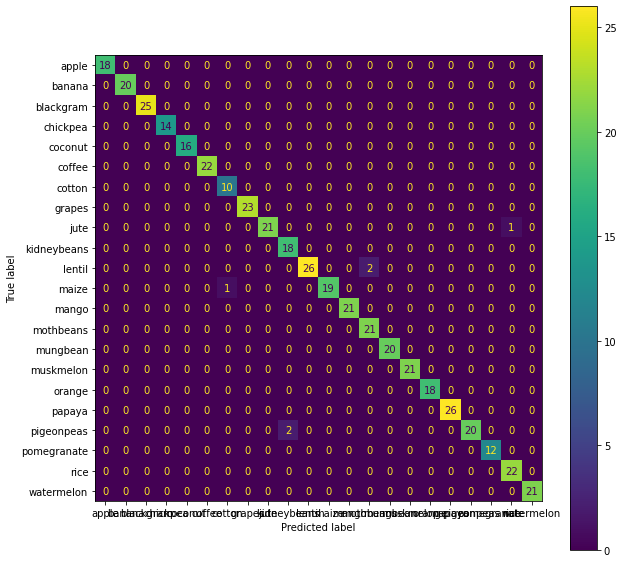

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(Y_test, al,ax=ax)

## **Learning Curve for AutoMl w.r.t Time and Accuracy**

In [ ]:
from flaml.data import get_output_from_log
time_history, best_valid_loss_history, valid_loss_history, config_history, metric_history = get_output_from_log(filename="crop_recommend.log", time_budget=60*60)

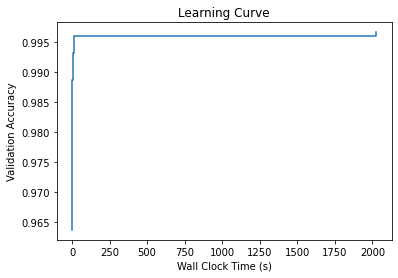

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.title("Learning Curve")
plt.xlabel("Wall Clock Time (s)")
plt.ylabel("Validation Accuracy")
plt.step(time_history, 1 - np.array(best_valid_loss_history), where="post")
plt.show()

## **Models trained in AutoMl and their best parameters**

In [ ]:
for i,j in zip(automl.best_config_per_estimator,automl.best_config_per_estimator.values()):
  print(i)
  print(j)

lgbm
{'n_estimators': 40, 'num_leaves': 5, 'min_child_samples': 5, 'learning_rate': 0.07321930874816164, 'log_max_bin': 5, 'colsample_bytree': 0.6753922366943279, 'reg_alpha': 0.0020219791484067384, 'reg_lambda': 0.00467506242405397}
extra_tree
{'n_estimators': 157, 'max_features': 0.7286146408405759, 'max_leaves': 91, 'criterion': 'entropy'}
xgb_limitdepth
{'n_estimators': 54, 'max_depth': 6, 'min_child_weight': 0.11058333468817735, 'learning_rate': 0.10171162893782969, 'subsample': 0.7599133320032065, 'colsample_bylevel': 0.5378655911056069, 'colsample_bytree': 0.8334379694753371, 'reg_alpha': 0.001914435024947312, 'reg_lambda': 0.001291157120186391}
lrl1
{'C': 1.7611241081939724}
xgboost
{'n_estimators': 44, 'max_leaves': 8, 'min_child_weight': 0.6588866122182211, 'learning_rate': 0.049108834055634924, 'subsample': 1.0, 'colsample_bylevel': 0.6879746019660484, 'colsample_bytree': 0.6531014185931541, 'reg_alpha': 0.005060117407810255, 'reg_lambda': 1.6607577099815742}
lrl2
{'C': 0.10

In [ ]:
Names.append('AUTOML_algorithm')
Accuracy.append(al_accuracy)

## **Bar graph for different algorithms accuracy**

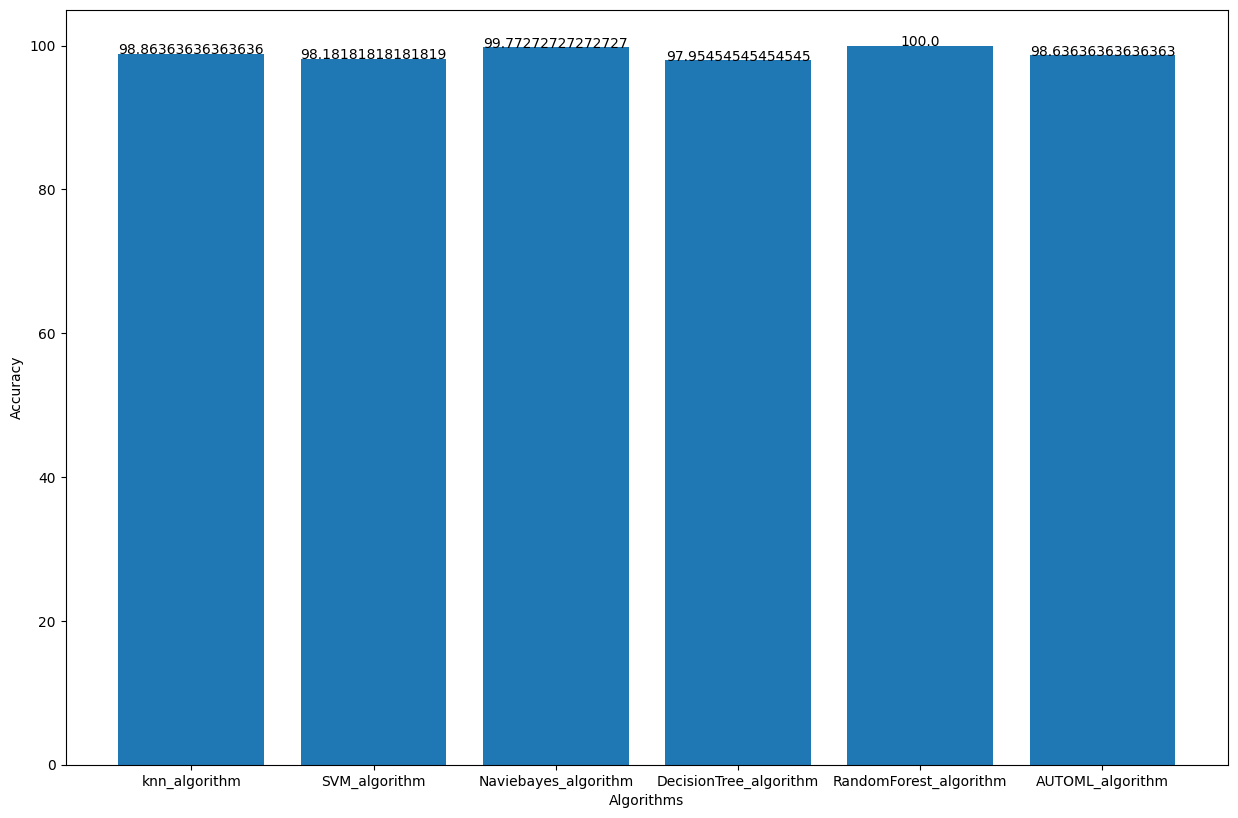

In [ ]:
plt.figure(figsize=[15,10],dpi=100)

plt.bar(Names,Accuracy)
for i in range(len(Names)):
  plt.text(i,Accuracy[i],Accuracy[i],ha = 'center')
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
#import matplotlib.pyplot as plt
#plt.bar(automl.model.estimator.feature_name_, automl.model.estimator.feature_importances_)

In [ ]:
#!pip install auto-sklearn

## **Automation using sklearn**

In [ ]:
"""
from autosklearn.classification import AutoSklearnClassifier
model = AutoSklearnClassifier(time_left_for_this_task=5*60)
model.fit(X_train,Y_train)
accuracy_score(Y_test,model.predict(X_test))*100
"""

## **Leaderboard of autosklearn**

In [ ]:
#model.leaderboard()

## **Statistics of autosklearn**

In [ ]:
#print(model.sprint_statistics())

In [ ]:
#data = np.array([[8,37, 40, 23.35905428, 83.53, 9.7, 106.91]])
#prediction = random.predict(data)
#print(prediction)